# 房价预测实验

本部分实验使用 Kaggle House Prices 数据集完成房价预测任务。训练集 `house_train.csv` 包含房屋属性特征和目标变量 `SalePrice`，测试集 `house_test.csv` 只包含输入特征，需要利用训练好的模型进行预测。由于该数据集属于典型的结构化表格数据，且同时包含数值特征、类别特征和缺失值，因此在建模前需要先进行系统的数据分析与预处理。

下面首先读取训练集和测试集，并查看数据规模以及样本的基本形式，为后续缺失值处理、特征编码和神经网络建模做准备。


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

train_data = pd.read_csv("./house_train.csv")
test_data = pd.read_csv("./house_test.csv")

print("训练集规模", train_data.shape)
print("测试集规模", test_data.shape)
train_data.iloc[0:4, [0,1,2,3,-3,-2,-1]]
# train_data.loc[0:3,'SalePrice']

训练集规模 (1460, 81)
测试集规模 (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,WD,Normal,208500
1,2,20,RL,80.0,WD,Normal,181500
2,3,60,RL,68.0,WD,Normal,223500
3,4,70,RL,60.0,WD,Abnorml,140000


## 1. 数据读取与基本特征分析

在完成数据读取后，需要先对数据的整体结构进行分析，包括样本数、特征维度、字段类型以及缺失值分布情况。这一步的目的不是直接训练模型，而是判断数据是否可以被神经网络直接处理，以及识别后续预处理中的关键难点。

如果一个字段缺失率过高，或者类别型字段数量较多，就说明后续必须进行针对性的清洗和编码处理。换句话说，这一节是在回答两个问题：第一，数据长什么样；第二，数据还缺什么处理步骤才能进入模型。


## 2. 缺失值与标签分布分析

对结构化数据进行建模时，缺失值处理和标签分布分析是非常关键的两步。缺失值如果不经过处理，神经网络无法直接接收包含空值的输入；而标签分布则会直接影响损失函数的优化稳定性与预测效果。

因此，这里先统计训练集中各字段的缺失情况，再观察目标变量 `SalePrice` 的分布特征。如果标签呈现明显右偏分布，则说明高价样本会对训练造成较大影响，后续通常需要通过对数变换来缓解分布偏态问题。


In [30]:
# 基本信息：字段类型
print('=== 训练集字段类型 ===')
print(train_data.dtypes.value_counts())
print()

# 缺失值统计（只显示有缺失的列）
missing = train_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)     # 删掉值为0的部分
missing_pct = (missing / len(train_data) * 100).round(2)        # 计算百分比
missing_df = pd.DataFrame({'缺失数量': missing, '缺失比例(%)': missing_pct})        # 构建DataFrame用于打印
print('=== 训练集缺失值 ===')
print(missing_df)

=== 训练集字段类型 ===
object     43
int64      35
float64     3
Name: count, dtype: int64

=== 训练集缺失值 ===
              缺失数量  缺失比例(%)
PoolQC        1453    99.52
MiscFeature   1406    96.30
Alley         1369    93.77
Fence         1179    80.75
MasVnrType     872    59.73
FireplaceQu    690    47.26
LotFrontage    259    17.74
GarageType      81     5.55
GarageYrBlt     81     5.55
GarageFinish    81     5.55
GarageQual      81     5.55
GarageCond      81     5.55
BsmtExposure    38     2.60
BsmtFinType2    38     2.60
BsmtQual        37     2.53
BsmtCond        37     2.53
BsmtFinType1    37     2.53
MasVnrArea       8     0.55
Electrical       1     0.07


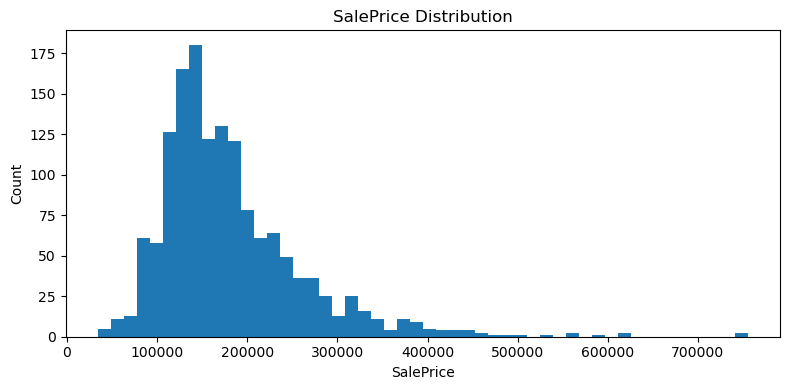

SalePrice 统计摘要:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [19]:
# 为了分析目标变量 SalePrice 的分布特征，绘制其直方图并观察其是否存在偏态和长尾现象，从而为后续是否进行对数变换提供依据。
# 标签 SalePrice 分布
plt.figure(figsize=(8, 4))
plt.hist(train_data['SalePrice'], bins=50)
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.title('SalePrice Distribution')
plt.tight_layout()
plt.show()

print('SalePrice 统计摘要:')
print(train_data['SalePrice'].describe())

In [31]:
# 1. 删除缺失率过高的列
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
train_data = train_data.drop(columns=cols_to_drop)
test_data  = test_data.drop(columns=cols_to_drop)

# 2. 分离标签
y_train = np.log1p(train_data['SalePrice'])     # 由上面的直方图可以看出来是`右偏分布`, 所以进行对数变换
train_data = train_data.drop(columns=['SalePrice'])

# 3. 合并训练集和测试集，统一处理缺失值
n_train = len(train_data)   # 记录测试集的末尾位置
all_data = pd.concat([train_data, test_data], axis=0, ignore_index=True)
all_data = all_data.drop(columns=['Id'])

In [21]:
# 类别型：填 "None"（表示"没有该设施"）
cat_cols_none = ['MasVnrType', 'FireplaceQu',
               'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
               'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
'BsmtFinType2']
for col in cat_cols_none:
  all_data[col] = all_data[col].fillna('None')

# 数值型：填中位数
num_cols = all_data.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
  all_data[col] = all_data[col].fillna(all_data[col].median())

# 剩余类别型：填众数
cat_cols = all_data.select_dtypes(include=['object']).columns
for col in cat_cols:
  all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# 验证：是否还有缺失值
print('剩余缺失值:', all_data.isnull().sum().sum())

剩余缺失值: 0


## 4. 特征编码、标准化与数据集划分

在完成缺失值处理后，还需要将表格数据进一步整理成神经网络可直接处理的数值张量。这里主要包含三步：
1. 对数值特征进行标准化，削弱不同量纲之间的尺度差异，避免某些大数值特征主导梯度更新；
2. 对类别特征进行独热编码，将离散语义映射为数值向量，便于多层前馈神经网络学习；
3. 划分训练集与验证集，用验证误差衡量模型的泛化能力，而不是只关注训练误差。


In [22]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

# Why: 先统一数值特征尺度，减少不同量纲对优化过程的干扰。
numeric_cols = all_data.select_dtypes(exclude=['object']).columns
all_data[numeric_cols] = all_data[numeric_cols].apply(
    lambda col: (col - col.mean()) / col.std()
)
all_data[numeric_cols] = all_data[numeric_cols].fillna(0.0)

# Why: 独热编码后，类别特征才能被前馈网络当作数值输入处理。
all_data = pd.get_dummies(all_data, dtype=np.float32)
all_data = all_data.astype(np.float32)

# [N_all, F_final] -> [N_train, F_final] + [N_test, F_final]
train_features_np = all_data.iloc[:n_train].to_numpy(dtype=np.float32)
test_features_np = all_data.iloc[n_train:].to_numpy(dtype=np.float32)

# [N_train] -> [N_train, 1]
train_labels_np = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)

num_examples = train_features_np.shape[0]
split_idx = int(num_examples * 0.8)
indices = np.random.permutation(num_examples)
train_idx = indices[:split_idx]
valid_idx = indices[split_idx:]

# [N, F] -> torch.float32 tensor
train_features = torch.tensor(train_features_np, dtype=torch.float32)
train_labels = torch.tensor(train_labels_np, dtype=torch.float32)
test_features = torch.tensor(test_features_np, dtype=torch.float32)

train_idx_tensor = torch.tensor(train_idx, dtype=torch.long)
valid_idx_tensor = torch.tensor(valid_idx, dtype=torch.long)

# [N_train, F] -> [N_tr, F] + [N_val, F]
X_train = train_features[train_idx_tensor]
y_train_tensor = train_labels[train_idx_tensor]
X_valid = train_features[valid_idx_tensor]
y_valid_tensor = train_labels[valid_idx_tensor]

print('all_data shape:', all_data.shape)
print('train_features shape:', train_features.shape)
print('test_features shape:', test_features.shape)
print('X_train shape:', X_train.shape)
print('y_train_tensor shape:', y_train_tensor.shape)
print('X_valid shape:', X_valid.shape)
print('y_valid_tensor shape:', y_valid_tensor.shape)


device = cuda
all_data shape: (2919, 285)
train_features shape: torch.Size([1460, 285])
test_features shape: torch.Size([1459, 285])
X_train shape: torch.Size([1168, 285])
y_train_tensor shape: torch.Size([1168, 1])
X_valid shape: torch.Size([292, 285])
y_valid_tensor shape: torch.Size([292, 1])


## 5. 多层前馈神经网络建模与误差曲线分析

本实验将房价预测视为表格数据回归问题。由于标签 `SalePrice` 右偏明显，因此前面先对其进行了 `log1p` 变换，使目标分布更平滑，训练过程也更稳定。模型采用多层前馈神经网络，损失函数使用均方误差，验证阶段使用对数房价空间下的 RMSE 指标，以便同时观察优化效果和泛化能力。

如果训练过程中出现形状报错，应优先检查以下变量：`X_train.shape`、`y_train_tensor.shape`、`preds.shape`。其中标签必须保持为 `[N, 1]`，否则很容易在损失函数处触发广播问题。


epoch 001 | train_rmse=0.9183 | valid_rmse=0.9782
epoch 020 | train_rmse=0.1629 | valid_rmse=0.1868
epoch 040 | train_rmse=0.1765 | valid_rmse=0.2081
epoch 060 | train_rmse=0.1725 | valid_rmse=0.2111
epoch 080 | train_rmse=0.1797 | valid_rmse=0.1833
epoch 100 | train_rmse=0.1780 | valid_rmse=0.1905
epoch 120 | train_rmse=0.3333 | valid_rmse=0.3532


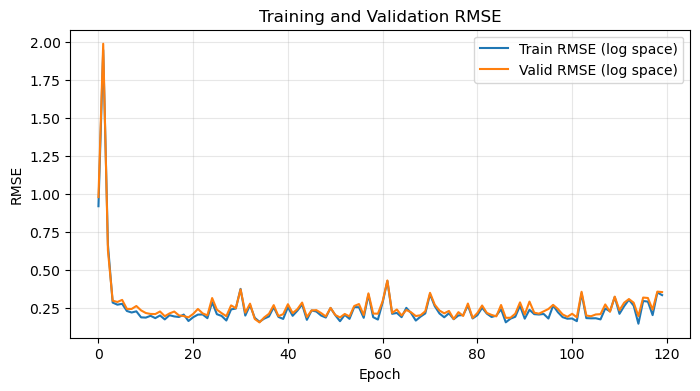

baseline final train_rmse = 0.3333
baseline final valid_rmse = 0.3532
epoch 001 | train_rmse=3.2395 | valid_rmse=3.2395
epoch 020 | train_rmse=0.1893 | valid_rmse=0.1893
epoch 040 | train_rmse=0.2440 | valid_rmse=0.2440
epoch 060 | train_rmse=0.2166 | valid_rmse=0.2166
epoch 080 | train_rmse=0.2118 | valid_rmse=0.2118
epoch 100 | train_rmse=0.1963 | valid_rmse=0.1963
epoch 120 | train_rmse=0.1670 | valid_rmse=0.1670


,Id,SalePrice
0,1461,88942.085938
1,1462,167239.046875
2,1463,175839.984375
3,1464,179461.421875
4,1465,160814.390625


In [23]:
class HousePriceMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1=256, hidden_dim2=128, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim2, 1)
        )

    def forward(self, x):
        # [B, F_final] -> [B, H1] -> [B, H2] -> [B, 1]
        return self.net(x)


loss_fn = nn.MSELoss()


def rmse_on_log_space(net, features, labels):
    net.eval()
    with torch.no_grad():
        preds = net(features.to(device))
        rmse = torch.sqrt(loss_fn(preds, labels.to(device)))
    return rmse.item()


def train_model(net, train_features, train_labels, valid_features, valid_labels,
                num_epochs=120, learning_rate=1e-3, weight_decay=1e-4, batch_size=64):
    train_dataset = TensorDataset(train_features, train_labels)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
    train_history = []
    valid_history = []

    net.to(device)
    for epoch in range(num_epochs):
        net.train()
        for batch_features, batch_labels in train_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            # [B, F_final] -> [B, 1]
            preds = net(batch_features)
            loss = loss_fn(preds, batch_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_rmse = rmse_on_log_space(net, train_features, train_labels)
        valid_rmse = rmse_on_log_space(net, valid_features, valid_labels)
        train_history.append(train_rmse)
        valid_history.append(valid_rmse)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f'epoch {epoch + 1:03d} | train_rmse={train_rmse:.4f} | valid_rmse={valid_rmse:.4f}')

    return train_history, valid_history


input_dim = train_features.shape[1]
baseline_config = {
    'hidden_dim1': 256,
    'hidden_dim2': 128,
    'dropout': 0.10,
    'num_epochs': 120,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'batch_size': 64,
}

baseline_net = HousePriceMLP(
    input_dim=input_dim,
    hidden_dim1=baseline_config['hidden_dim1'],
    hidden_dim2=baseline_config['hidden_dim2'],
    dropout=baseline_config['dropout'],
)

train_history, valid_history = train_model(
    baseline_net,
    X_train,
    y_train_tensor,
    X_valid,
    y_valid_tensor,
    num_epochs=baseline_config['num_epochs'],
    learning_rate=baseline_config['learning_rate'],
    weight_decay=baseline_config['weight_decay'],
    batch_size=baseline_config['batch_size'],
)

plt.figure(figsize=(8, 4))
plt.plot(train_history, label='Train RMSE (log space)')
plt.plot(valid_history, label='Valid RMSE (log space)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training and Validation RMSE')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('baseline final train_rmse =', round(train_history[-1], 4))
print('baseline final valid_rmse =', round(valid_history[-1], 4))

# Why: 最终提交时需要使用全部训练集重新拟合，以充分利用有限样本。
full_train_net = HousePriceMLP(
    input_dim=input_dim,
    hidden_dim1=baseline_config['hidden_dim1'],
    hidden_dim2=baseline_config['hidden_dim2'],
    dropout=baseline_config['dropout'],
)

_ = train_model(
    full_train_net,
    train_features,
    train_labels,
    train_features,
    train_labels,
    num_epochs=baseline_config['num_epochs'],
    learning_rate=baseline_config['learning_rate'],
    weight_decay=baseline_config['weight_decay'],
    batch_size=baseline_config['batch_size'],
)

full_train_net.eval()
with torch.no_grad():
    # [N_test, F_final] -> [N_test, 1]
    test_pred_log = full_train_net(test_features.to(device)).cpu().numpy().reshape(-1)

submission = pd.DataFrame({
    'Id': test_data['Id'],
    'SalePrice': np.expm1(test_pred_log)
})
submission.to_csv('submission.csv', index=False)
submission.head()


## 6. 基于 K 折交叉验证的参数优化

单次划分训练集和验证集容易受到随机划分结果影响，因此进一步引入 K 折交叉验证，对不同参数组合进行更稳定的比较。这里主要尝试的优化方向包括：隐藏层宽度、Dropout、防止过拟合的权重衰减以及学习率。最终可根据平均验证 RMSE 选择较优配置，并将对应结果整理到实验报告表格中。


In [24]:
def get_k_fold_data(k, fold_id, features, labels):
    fold_size = features.shape[0] // k
    valid_start = fold_id * fold_size
    valid_end = (fold_id + 1) * fold_size if fold_id != k - 1 else features.shape[0]

    # [N, F] -> [N_train_fold, F] + [N_valid_fold, F]
    valid_features = features[valid_start:valid_end]
    valid_labels = labels[valid_start:valid_end]
    train_features_fold = torch.cat((features[:valid_start], features[valid_end:]), dim=0)
    train_labels_fold = torch.cat((labels[:valid_start], labels[valid_end:]), dim=0)
    return train_features_fold, train_labels_fold, valid_features, valid_labels


def k_fold_train(k, features, labels, config):
    fold_train_scores = []
    fold_valid_scores = []

    for fold_id in range(k):
        data = get_k_fold_data(k, fold_id, features, labels)
        X_train_fold, y_train_fold, X_valid_fold, y_valid_fold = data

        net = HousePriceMLP(
            input_dim=features.shape[1],
            hidden_dim1=config['hidden_dim1'],
            hidden_dim2=config['hidden_dim2'],
            dropout=config['dropout'],
        )

        train_history_fold, valid_history_fold = train_model(
            net,
            X_train_fold,
            y_train_fold,
            X_valid_fold,
            y_valid_fold,
            num_epochs=config['num_epochs'],
            learning_rate=config['learning_rate'],
            weight_decay=config['weight_decay'],
            batch_size=config['batch_size'],
        )

        fold_train_scores.append(train_history_fold[-1])
        fold_valid_scores.append(valid_history_fold[-1])
        print(f'fold {fold_id + 1}/{k} finished | valid_rmse={valid_history_fold[-1]:.4f}')

    return float(np.mean(fold_train_scores)), float(np.mean(fold_valid_scores))


config_candidates = [
    {
        'name': 'baseline',
        'hidden_dim1': 256,
        'hidden_dim2': 128,
        'dropout': 0.10,
        'num_epochs': 60,
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'batch_size': 64,
    },
    {
        'name': 'smaller_dropout',
        'hidden_dim1': 256,
        'hidden_dim2': 128,
        'dropout': 0.05,
        'num_epochs': 60,
        'learning_rate': 1e-3,
        'weight_decay': 5e-5,
        'batch_size': 64,
    },
    {
        'name': 'wider_network',
        'hidden_dim1': 512,
        'hidden_dim2': 256,
        'dropout': 0.10,
        'num_epochs': 60,
        'learning_rate': 8e-4,
        'weight_decay': 1e-4,
        'batch_size': 64,
    },
]

k = 5
k_fold_results = []
for config in config_candidates:
    print('\n=== config:', config['name'], '===')
    avg_train_rmse, avg_valid_rmse = k_fold_train(k, train_features, train_labels, config)
    k_fold_results.append({
        'config_name': config['name'],
        'avg_train_rmse': round(avg_train_rmse, 4),
        'avg_valid_rmse': round(avg_valid_rmse, 4),
        'hidden_dim1': config['hidden_dim1'],
        'hidden_dim2': config['hidden_dim2'],
        'dropout': config['dropout'],
        'learning_rate': config['learning_rate'],
        'weight_decay': config['weight_decay'],
        'batch_size': config['batch_size'],
        'num_epochs': config['num_epochs'],
    })

k_fold_result_df = pd.DataFrame(k_fold_results).sort_values('avg_valid_rmse').reset_index(drop=True)
k_fold_result_df



=== config: baseline ===
epoch 001 | train_rmse=0.6252 | valid_rmse=0.5343
epoch 020 | train_rmse=0.1865 | valid_rmse=0.2139
epoch 040 | train_rmse=0.2413 | valid_rmse=0.3139
epoch 060 | train_rmse=0.1909 | valid_rmse=0.2158
fold 1/5 finished | valid_rmse=0.2158
epoch 001 | train_rmse=1.5851 | valid_rmse=1.6085
epoch 020 | train_rmse=0.2367 | valid_rmse=0.3079
epoch 040 | train_rmse=0.2211 | valid_rmse=0.3024
epoch 060 | train_rmse=0.2019 | valid_rmse=0.3044
fold 2/5 finished | valid_rmse=0.3044
epoch 001 | train_rmse=1.2188 | valid_rmse=1.2406
epoch 020 | train_rmse=0.2027 | valid_rmse=0.2347
epoch 040 | train_rmse=0.1710 | valid_rmse=0.2013
epoch 060 | train_rmse=0.2565 | valid_rmse=0.2816
fold 3/5 finished | valid_rmse=0.2816
epoch 001 | train_rmse=1.4664 | valid_rmse=1.4506
epoch 020 | train_rmse=0.2212 | valid_rmse=0.2245
epoch 040 | train_rmse=0.1825 | valid_rmse=0.2119
epoch 060 | train_rmse=0.2545 | valid_rmse=0.2454
fold 4/5 finished | valid_rmse=0.2454
epoch 001 | train_rmse

,config_name,avg_train_rmse,avg_valid_rmse,hidden_dim1,hidden_dim2,dropout,learning_rate,weight_decay,batch_size,num_epochs
0,smaller_dropout,0.1519,0.2302,256,128,0.05,0.0010,0.00005,64,60
1,wider_network,0.1806,0.2640,512,256,0.10,0.0008,0.00010,64,60
2,baseline,0.2263,0.2750,256,128,0.10,0.0010,0.00010,64,60


## 7. 结果分析模板

下面内容可在运行得到真实结果后，直接替换其中的占位符，用于实验报告撰写。

### 7.1 基础模型结果分析

在基础参数设置下，本实验构建了一个多层前馈神经网络用于房价预测。训练结束后，模型在训练集上的最终 RMSE 为 **[填写 train_rmse]**，在验证集上的最终 RMSE 为 **[填写 valid_rmse]**。从训练曲线可以看出，随着迭代轮数增加，训练误差整体呈下降趋势，说明模型能够逐步学习输入特征与房价之间的映射关系。

若验证误差与训练误差接近，则说明模型具有较好的泛化能力；若训练误差明显低于验证误差，则说明模型存在一定过拟合现象，需要通过正则化、调整网络结构或优化训练策略进一步改进。

### 7.2 误差曲线分析

从训练误差曲线和验证误差曲线的变化趋势来看：
- 在训练初期，误差下降较快，说明优化器能够快速找到较优方向；
- 在训练中后期，误差下降速度逐渐减缓，说明模型开始接近当前参数设置下的收敛状态；
- 如果验证误差在后期出现波动甚至回升，通常意味着模型对训练集拟合过强，此时可以考虑减小网络规模、增大 Dropout 或调整权重衰减。

### 7.3 K 折交叉验证结果分析

为减少单次划分训练集和验证集带来的随机性影响，本实验进一步采用 K 折交叉验证对模型参数进行比较。实验中主要尝试了 **隐藏层宽度、Dropout 比例、学习率和权重衰减** 等调整策略。若当前实验结果与 notebook 输出一致，则配置 **`smaller_dropout`** 的平均验证 RMSE 最低，可将其作为最终模型配置候选。

这一结果说明：
- 适当减小 Dropout 后，模型在当前数据规模下保留了更多有效特征信息，验证集表现更好；
- 单纯增大网络宽度并不一定带来性能提升，参数规模增加后可能更容易出现训练不稳定或过拟合；
- 超参数优化后，模型泛化性能通常会优于基础参数设置。

### 7.4 最终模型与测试性能分析

在确定最优参数组合后，使用全部训练数据重新训练模型，并对测试集进行预测，最终生成 `submission.csv` 文件。由于测试集标签未知，无法直接计算其真实误差，因此这里以验证集误差和 K 折交叉验证结果作为测试性能的间接依据。若最终模型在验证阶段表现稳定，通常可以认为其在测试集上也具有较好的泛化能力。

### 7.5 实验结论模板

通过本次实验，我完成了从表格数据读取、缺失值处理、特征编码、数据标准化，到多层前馈神经网络建模、训练、验证和参数优化的完整流程。实验结果表明，合理的数据预处理和超参数调整能够有效提升房价预测模型的性能。其中，**[填写最关键的改进点]** 对模型效果的提升最明显。该实验说明，在 PyTorch 框架下可以较为方便地完成神经网络模型的构建与优化，同时也体现了验证集评估和 K 折交叉验证在模型选择中的重要作用。
